# パッケージインストール

In [1]:
!pip install -q transformers==4.57.1
!pip install -q decord==0.6.0
!pip install -q lmdb==1.7.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 149.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 126.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 9.6 MB/s eta 0:00:00


In [2]:
# MagiAttention（Hopper / Blackwell GPUのみ、MTP推論の高速化に推奨）
# !git clone https://github.com/SandAI-org/MagiAttention.git
# %cd MagiAttention
# !git checkout v1.0.5
# !git submodule update --init --recursive
# !pip install -r requirements.txt
# !pip install --no-build-isolation .

# LocateAnything Utility func

In [3]:
import re
import torch
from PIL import Image
from transformers import AutoModel, AutoTokenizer, AutoProcessor


class LocateAnythingWorker:
    """Stateful worker that loads the model once and serves perception queries."""

    def __init__(self, model_path: str, device: str = "cuda", dtype=torch.bfloat16):
        self.device = device
        self.dtype = dtype

        self.tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
        self.processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)
        self.model = AutoModel.from_pretrained(
            model_path,
            torch_dtype=dtype,
            trust_remote_code=True,
        ).to(device).eval()

    @torch.no_grad()
    def predict(
        self,
        image: Image.Image,
        question: str,
        generation_mode: str = "hybrid",   # "fast" (MTP) | "slow" (NTP/AR) | "hybrid"
        max_new_tokens: int = 2048,
        temperature: float = 0.7,
        verbose: bool = True,
    ) -> dict:
        messages = [
            {"role": "user", "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ]}
        ]

        text = self.processor.py_apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        images, videos = self.processor.process_vision_info(messages)
        inputs = self.processor(
            text=[text], images=images, videos=videos, return_tensors="pt"
        ).to(self.device)

        pixel_values = inputs["pixel_values"].to(self.dtype)
        input_ids = inputs["input_ids"]
        image_grid_hws = inputs.get("image_grid_hws", None)

        response = self.model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=inputs["attention_mask"],
            image_grid_hws=image_grid_hws,
            tokenizer=self.tokenizer,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            generation_mode=generation_mode,
            temperature=temperature,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            verbose=verbose,
        )

        result = {"answer": response[0] if isinstance(response, tuple) else response}
        if isinstance(response, tuple) and len(response) >= 3:
            result["history"] = response[1]
            result["stats"] = response[2]
        return result

    # ---- Convenience methods for each task ----

    def detect(self, image: Image.Image, categories: list[str], **kwargs) -> dict:
        """Object detection / document layout analysis."""
        cats = "</c>".join(categories)
        prompt = f"Locate all the instances that matches the following description: {cats}."
        return self.predict(image, prompt, **kwargs)

    def ground_single(self, image: Image.Image, phrase: str, **kwargs) -> dict:
        """Phrase grounding — single instance."""
        prompt = f"Locate a single instance that matches the following description: {phrase}."
        return self.predict(image, prompt, **kwargs)

    def ground_multi(self, image: Image.Image, phrase: str, **kwargs) -> dict:
        """Phrase grounding — multiple instances."""
        prompt = f"Locate all the instances that match the following description: {phrase}."
        return self.predict(image, prompt, **kwargs)

    def ground_text(self, image: Image.Image, phrase: str, **kwargs) -> dict:
        """Text grounding."""
        prompt = f"Please locate the text referred as {phrase}."
        return self.predict(image, prompt, **kwargs)

    def detect_text(self, image: Image.Image, **kwargs) -> dict:
        """Scene text detection."""
        prompt = "Detect all the text in box format."
        return self.predict(image, prompt, **kwargs)

    def ground_gui(self, image: Image.Image, phrase: str, output_type: str = "box", **kwargs) -> dict:
        """GUI grounding (box or point)."""
        if output_type == "point":
            prompt = f"Point to: {phrase}."
        else:
            prompt = f"Locate the region that matches the following description: {phrase}."
        return self.predict(image, prompt, **kwargs)

    def point(self, image: Image.Image, phrase: str, **kwargs) -> dict:
        """Pointing."""
        prompt = f"Point to: {phrase}."
        return self.predict(image, prompt, **kwargs)

    # ---- Utility: parse model output ----

    @staticmethod
    def parse_boxes(answer: str, image_width: int, image_height: int) -> list[dict]:
        """Parse model output into pixel-coordinate bounding boxes with labels.

        Coordinates in model output are normalized integers in [0, 1000].

        Example:
            <ref>person</ref><box><54><281><114><516></box>
            <ref>car</ref><box><671><317><848><594></box>
        """
        boxes = []
        current_label = None

        pattern = r"<ref>(.*?)</ref>|<box><(\d+)><(\d+)><(\d+)><(\d+)></box>"

        for m in re.finditer(pattern, answer):
            label, x1, y1, x2, y2 = m.groups()

            if label is not None:
                current_label = label
                continue

            boxes.append({
                "label": current_label,
                "x1": int(x1) / 1000 * image_width,
                "y1": int(y1) / 1000 * image_height,
                "x2": int(x2) / 1000 * image_width,
                "y2": int(y2) / 1000 * image_height,
            })

        return boxes

    @staticmethod
    def parse_points(answer: str, image_width: int, image_height: int) -> list[dict]:
        """Parse model output into pixel-coordinate points with labels."""

        points = []
        current_label = None

        pattern = r"<ref>(.*?)</ref>|<box><(\d+)><(\d+)></box>"

        for m in re.finditer(pattern, answer):
            label, x, y = m.groups()

            if label is not None:
                current_label = label
                continue

            points.append({
                "label": current_label,
                "x": int(x) / 1000 * image_width,
                "y": int(y) / 1000 * image_height,
            })

        return points


In [4]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize(image, boxes, points):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    # Generate colors for all labels
    labels = {
        item.get("label", "unknown")
        for item in boxes + points
    }

    labels = sorted(labels)

    cmap = cm.get_cmap("tab20", max(len(labels), 1))

    label_colors = {
        label: cmap(i)
        for i, label in enumerate(labels)
    }

    # Draw Bounding Boxes
    for box in boxes:
        label = box.get("label", "unknown")
        color = label_colors[label]

        rect = patches.Rectangle(
            (box["x1"], box["y1"]),
            box["x2"] - box["x1"],
            box["y2"] - box["y1"],
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)

        ax.text(
            box["x1"],
            max(0, box["y1"] - 5),
            label,
            fontsize=10,
            color="white",
            bbox={
                "facecolor": color,
                "edgecolor": color,
                "pad": 2,
            },
        )

    # Draw Points
    for pt in points:
        label = pt.get("label", "unknown")
        color = label_colors[label]

        circle = patches.Circle(
            (pt["x"], pt["y"]),
            radius=5,
            color=color,
        )
        ax.add_patch(circle)

        ax.text(
            pt["x"] + 8,
            pt["y"] - 8,
            label,
            fontsize=10,
            color="white",
            bbox={
                "facecolor": color,
                "edgecolor": color,
                "pad": 2,
            },
        )

    plt.axis("off")
    plt.show()

# モデル読み込み

In [5]:
worker = LocateAnythingWorker("nvidia/LocateAnything-3B")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.70G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

# 画像読み込み

In [8]:
!wget https://raw.githubusercontent.com/Kazuhito00/LocateAnything-Colaboratory-Example/refs/heads/main/sample.jpg -O example.jpg

--2026-06-02 00:48:36--  https://raw.githubusercontent.com/Kazuhito00/LocateAnything-Colaboratory-Example/refs/heads/main/sample.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 96400 (94K) [image/jpeg]
Saving to: ‘example.jpg’

example.jpg         100%[===================>]  94.14K  --.-KB/s    in 0.01s   

2026-06-02 00:48:36 (8.64 MB/s) - ‘example.jpg’ saved [96400/96400]



In [9]:
img = Image.open("example.jpg").convert("RGB")

# Object Detection

In [10]:
%%time
# Object Detection
result = worker.detect(img, ["person", "car", "bicycle"])

# Parse structured output into pixel coordinates
w, h = img.size
boxes = LocateAnythingWorker.parse_boxes(result["answer"], w, h)
points = LocateAnythingWorker.parse_points(result["answer"], w, h)

/root/.cache/huggingface/modules/transformers_modules/nvidia/LocateAnything_hyphen_3B/7a81d810571dc5f244b2f0b6868128f24b1cbd85/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))



Statistic Info, num_tokens=179; generate_time(s)=5.3465; tps=33.4796; forward_step=55; num_boxes=28; bps=5.2370; prefill_time=2.2314; switch_to_ar=6

CPU times: user 4.18 s, sys: 107 ms, total: 4.29 s
Wall time: 5.4 s


/tmp/ipykernel_2520/941094062.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(len(labels), 1))


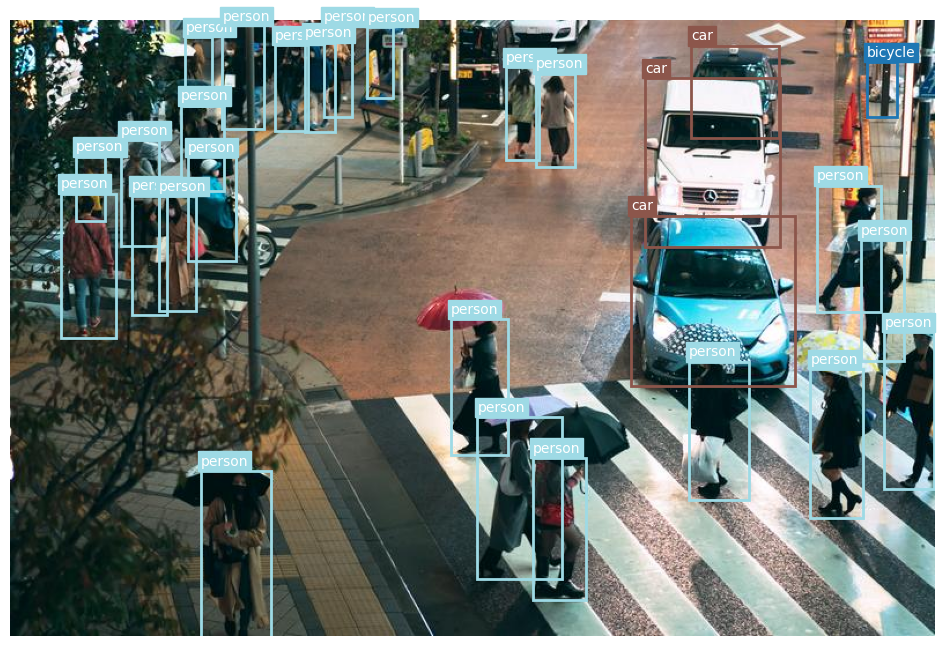

In [12]:
visualize(img, boxes, points)

In [13]:
%%time
# Phrase Grounding (multiple)
result = worker.ground_multi(img, "people wearing red shirts")

# Parse structured output into pixel coordinates
w, h = img.size
boxes = LocateAnythingWorker.parse_boxes(result["answer"], w, h)
points = LocateAnythingWorker.parse_points(result["answer"], w, h)


Statistic Info, num_tokens=19; generate_time(s)=1.0596; tps=17.9314; forward_step=9; num_boxes=2; bps=1.8875; prefill_time=0.6360; switch_to_ar=1

CPU times: user 1.13 s, sys: 3.5 ms, total: 1.13 s
Wall time: 1.08 s


/tmp/ipykernel_2520/941094062.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(len(labels), 1))


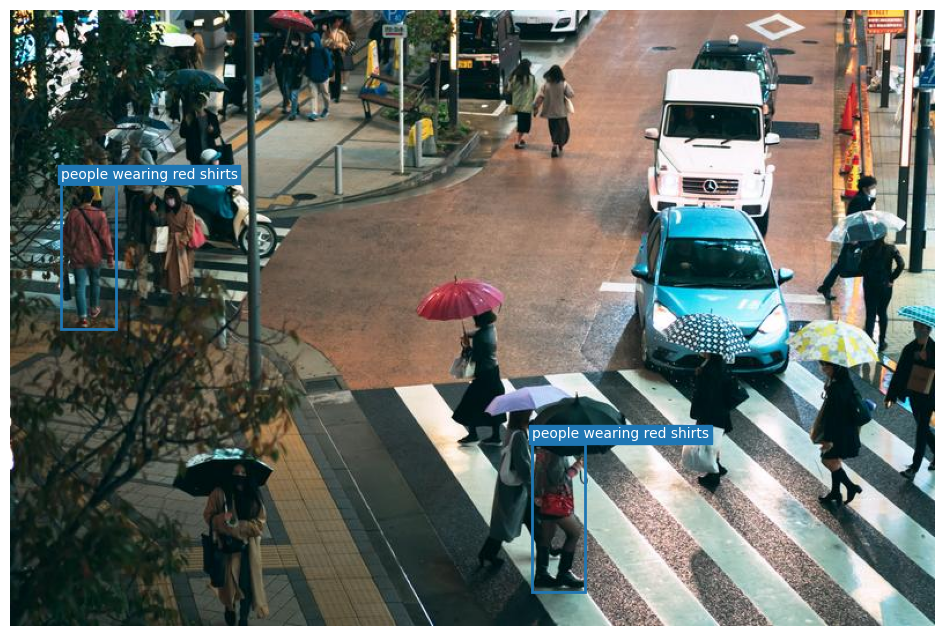

In [14]:
visualize(img, boxes, points)

# Pointing

In [15]:
%%time
# Pointing
result = worker.point(img, "the traffic sign")

# Parse structured output into pixel coordinates
w, h = img.size
boxes = LocateAnythingWorker.parse_boxes(result["answer"], w, h)
points = LocateAnythingWorker.parse_points(result["answer"], w, h)


Statistic Info, num_tokens=10; generate_time(s)=0.7466; tps=13.3946; forward_step=3; num_boxes=1; bps=1.3395; prefill_time=0.6333; switch_to_ar=0

CPU times: user 803 ms, sys: 13.9 ms, total: 817 ms
Wall time: 767 ms


/tmp/ipykernel_2520/941094062.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(len(labels), 1))


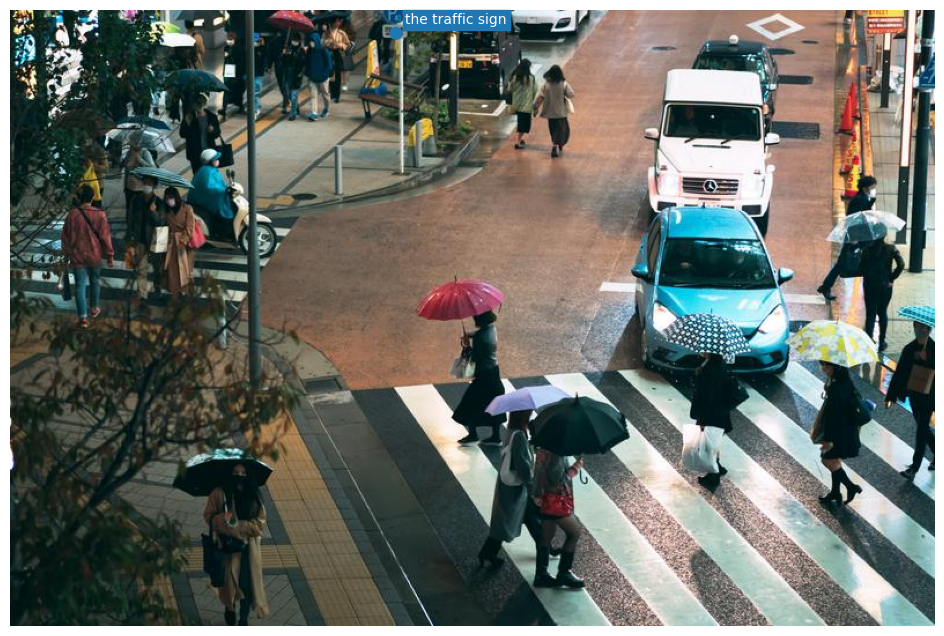

In [16]:
visualize(img, boxes, points)

In [17]:
%%time
# GUI Grounding (point)
result = worker.ground_gui(img, "Mercedes-Benz symbol", output_type="point")

# Parse structured output into pixel coordinates
w, h = img.size
boxes = LocateAnythingWorker.parse_boxes(result["answer"], w, h)
points = LocateAnythingWorker.parse_points(result["answer"], w, h)


Statistic Info, num_tokens=11; generate_time(s)=0.7465; tps=14.7356; forward_step=3; num_boxes=1; bps=1.3396; prefill_time=0.6323; switch_to_ar=0

CPU times: user 806 ms, sys: 0 ns, total: 806 ms
Wall time: 765 ms


/tmp/ipykernel_2520/941094062.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(len(labels), 1))


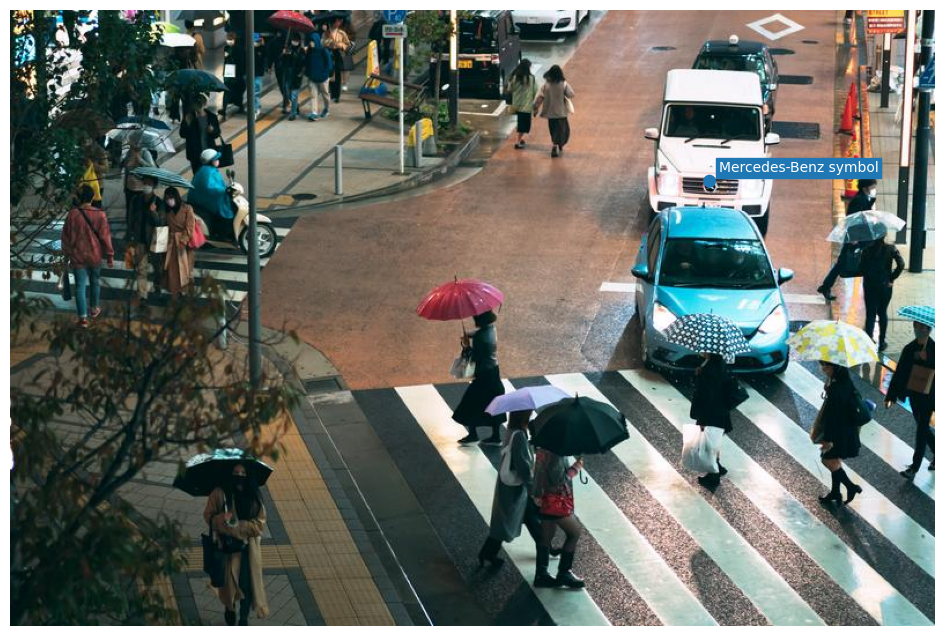

In [18]:
visualize(img, boxes, points)